# Student Performance Risk Analysis

## Objective
Analyze which factors most strongly influence a student's final grade (G3)
and identify what puts students at risk of failing.

This analysis focuses on understanding whether attendance, study habits,
and background variables actually matter compared to early academic performance.


## Dataset
The dataset contains student academic and demographic data including:

- absences: Number of classes missed
- G1: First period grade
- G2: Second period grade
- G3: Final grade
- failures: Number of past class failures
- studytime: Weekly study time


In [4]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\hp\OneDrive\Desktop\data analytics\student-attendance-performance-analytics\data\student-mat.csv",
    sep=";"
)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
df["absences"].corr(df["G3"])


np.float64(0.03424731615006934)

In [6]:
df.corr(numeric_only=True)["G3"].sort_values(ascending=False)


G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\hp\OneDrive\Desktop\data analytics\student-attendance-performance-analytics\data\student-mat.csv",
    sep=";"
)

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Methodology
We analyze correlations between each numeric feature and the final grade (G3),
and also create a risk label (at_risk) to understand what drives academic failure.


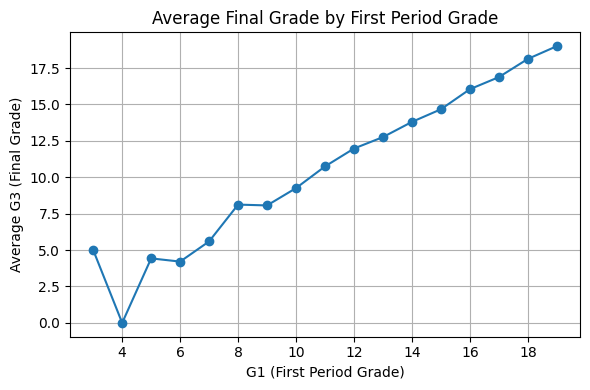

In [6]:
import matplotlib.pyplot as plt

# Group by G1 and take average of G3
g1_trend = df.groupby("G1")["G3"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(g1_trend["G1"], g1_trend["G3"], marker="o")

plt.xlabel("G1 (First Period Grade)")
plt.ylabel("Average G3 (Final Grade)")
plt.title("Average Final Grade by First Period Grade")
plt.grid(True)
plt.tight_layout()
plt.show()



In [4]:
df[["studytime", "failures", "G1", "G2", "absences", "G3"]].corr()["G3"].sort_values(ascending=False)


G3           1.000000
G2           0.904868
G1           0.801468
studytime    0.097820
absences     0.034247
failures    -0.360415
Name: G3, dtype: float64

In [2]:

import pandas as pd

df = pd.read_csv("../data/student-mat.csv", sep=";")
df.head()



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


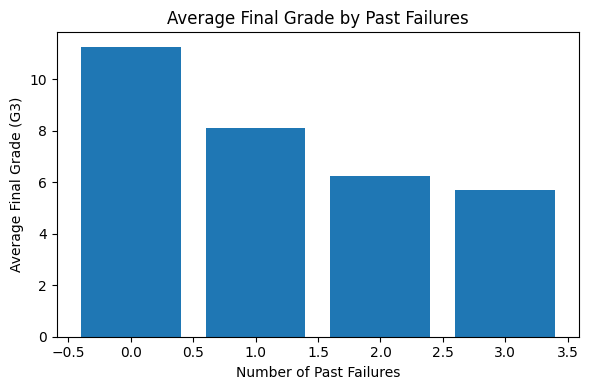

In [7]:
import matplotlib.pyplot as plt

# Group by number of failures and compute average final grade
fail_trend = df.groupby("failures")["G3"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(fail_trend["failures"], fail_trend["G3"])

plt.xlabel("Number of Past Failures")
plt.ylabel("Average Final Grade (G3)")
plt.title("Average Final Grade by Past Failures")
plt.tight_layout()
plt.show()



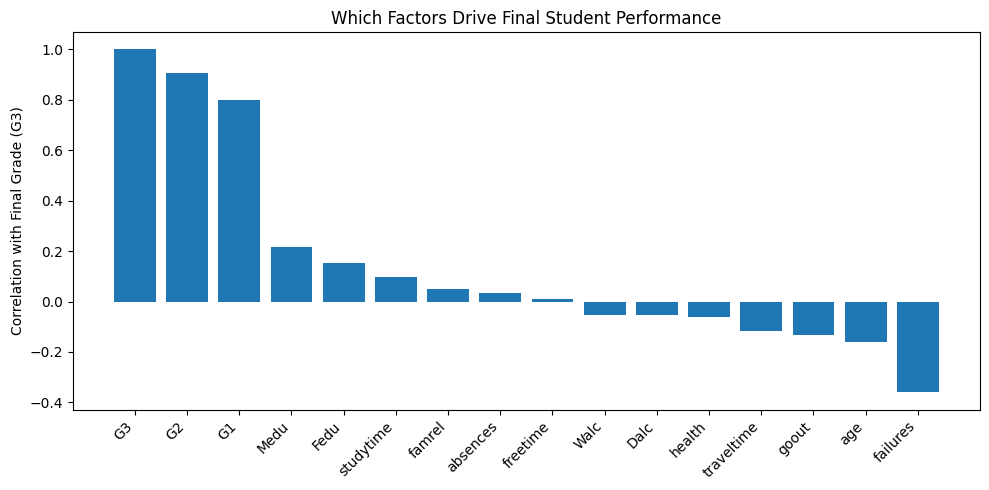

In [8]:
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include=["int64","float64"])
corr = num_df.corr()["G3"].sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(corr.index, corr.values)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation with Final Grade (G3)")
plt.title("Which Factors Drive Final Student Performance")

plt.tight_layout()
plt.show()



## Conclusion

This analysis shows that final academic performance is driven primarily by
early academic results and prior failures, not by attendance or reported
study time.

Students who perform well in the first and second periods almost always
maintain strong final grades, while students with past failures are far more
likely to be at risk, regardless of attendance.

This suggests that early intervention based on academic performance is far
more effective than policies focused only on attendance.
